# 06 SHAP Model Explainability

This notebook applies SHAP (SHapley Additive exPlanations) to interpret the trained Logistic Regression model from Step 5. It uses the `model_artifacts.pkl` to scale and select features prior to explanation.

In [1]:
# Install shap into the current Jupyter kernel
%pip install shap -q

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import pickle
import duckdb
import shap
import matplotlib.pyplot as plt

# Initialize JS visualization for SHAP if running interactively
shap.initjs()

/Users/sameer/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load Model Artifacts
artifacts_path = '../model_artifacts.pkl'
with open(artifacts_path, 'rb') as f:
    artifacts = pickle.load(f)

scaler = artifacts['scaler']
selector = artifacts['selector']
lr = artifacts['model']
feature_names = artifacts['selected_features']

In [4]:
# Connect to DuckDB and load the training and test data
from utils import get_db_connection
con = get_db_connection()

X_train = con.execute("SELECT * FROM X_train").fetchdf()
X_test = con.execute("SELECT * FROM X_test").fetchdf()

# Preprocess X_train and X_test using the saved scaler and selector
X_train_selected = selector.transform(X_train)
X_train_scaled = scaler.transform(X_train_selected)

X_test_selected = selector.transform(X_test)
X_test_scaled = scaler.transform(X_test_selected)

# Create DataFrames with selected features for easier interpretation in SHAP
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

Connected to DuckDB at: /Users/sameer/Documents/DataScience_Capstone_Project/Capstone_Healthcare_Decision_Intelligence_Agent/dataset/hf_project.duckdb


In [5]:
# Initialize SHAP LinearExplainer for the Logistic Regression model
# We use X_train_selected to represent the background distribution
explainer = shap.LinearExplainer(lr, X_train_selected)

# Compute SHAP values for the test set
shap_values = explainer(X_test_selected)

# Ensure the feature names are matched correctly
shap_values.feature_names = feature_names

# Save the explainer to artifacts so we can use it in the Streamlit app
artifacts['explainer'] = explainer
with open(artifacts_path, 'wb') as f:
    pickle.dump(artifacts, f)
print("Updated model_artifacts.pkl with SHAP explainer!")

Updated model_artifacts.pkl with SHAP explainer!


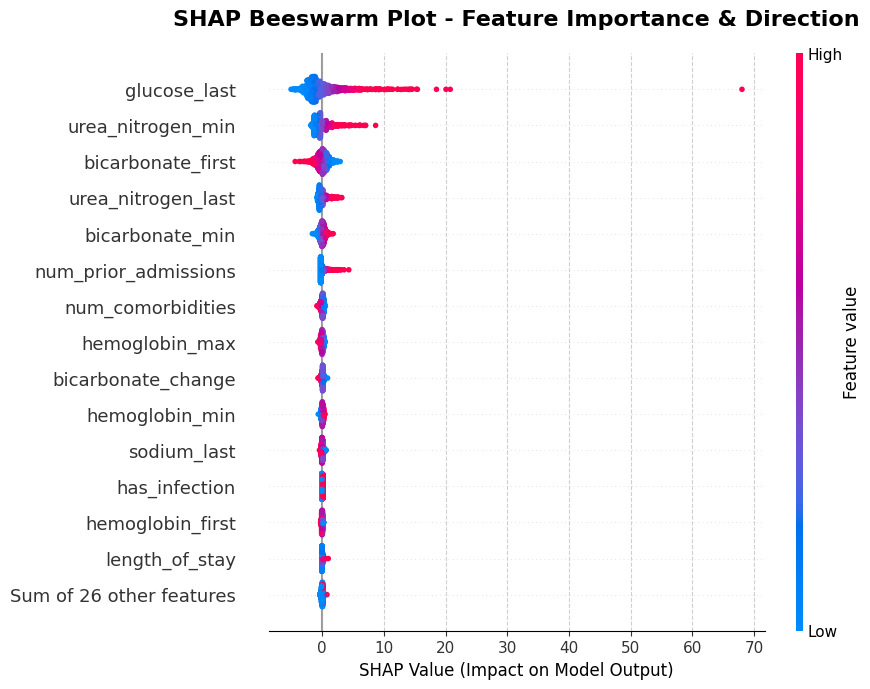

In [6]:
# 1. SHAP Beeswarm Plot (Global Feature Importance - Improved)
plt.figure(figsize=(12, 8))
# Use beeswarm plot which is the modern standard for Explanation objects
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm Plot - Feature Importance & Direction", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('../results/shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

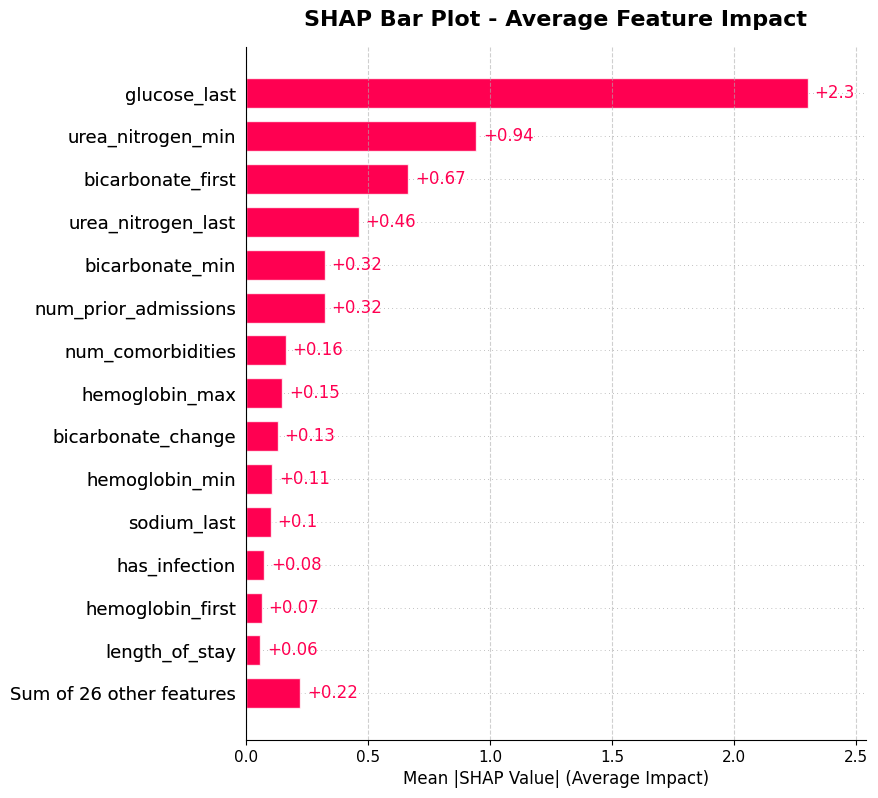

In [7]:
# 2. SHAP Bar Plot (Mean Absolute SHAP Value - Improved)
plt.figure(figsize=(12, 8))
# Use the modern bar plot API for Explanation objects
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Bar Plot - Average Feature Impact", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Mean |SHAP Value| (Average Impact)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('../results/shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

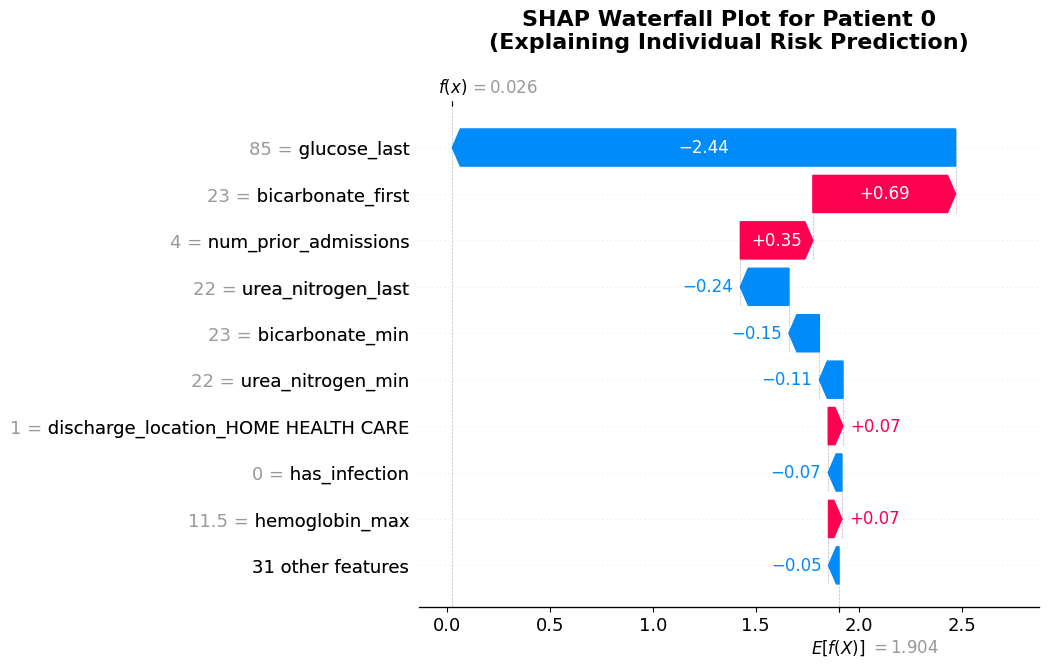

In [8]:
# 3. SHAP Waterfall Plot for a single patient (Local Explainability - Improved)
# Take the first patient in the test set as an example
patient_idx = 0

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_values[patient_idx], max_display=10, show=False)
plt.title(f"SHAP Waterfall Plot for Patient {patient_idx}\n(Explaining Individual Risk Prediction)", fontsize=16, fontweight='bold', pad=20)
plt.savefig(f'../results/shap_waterfall_patient_{patient_idx}.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

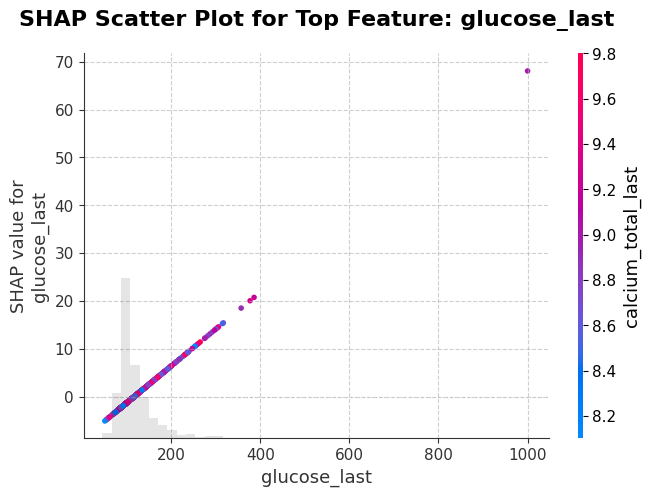

In [9]:
# 4. SHAP Scatter Plot (Feature Interaction - Added)
# Check the top feature by max mean absolute SHAP value
top_feature_idx = np.argsort(-np.abs(shap_values.values).mean(0))[0]
top_feature_name = feature_names[top_feature_idx]

plt.figure(figsize=(10, 6))
shap.plots.scatter(shap_values[:, top_feature_name], color=shap_values, show=False)
plt.title(f"SHAP Scatter Plot for Top Feature: {top_feature_name}", fontsize=16, fontweight='bold', pad=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('../results/shap_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

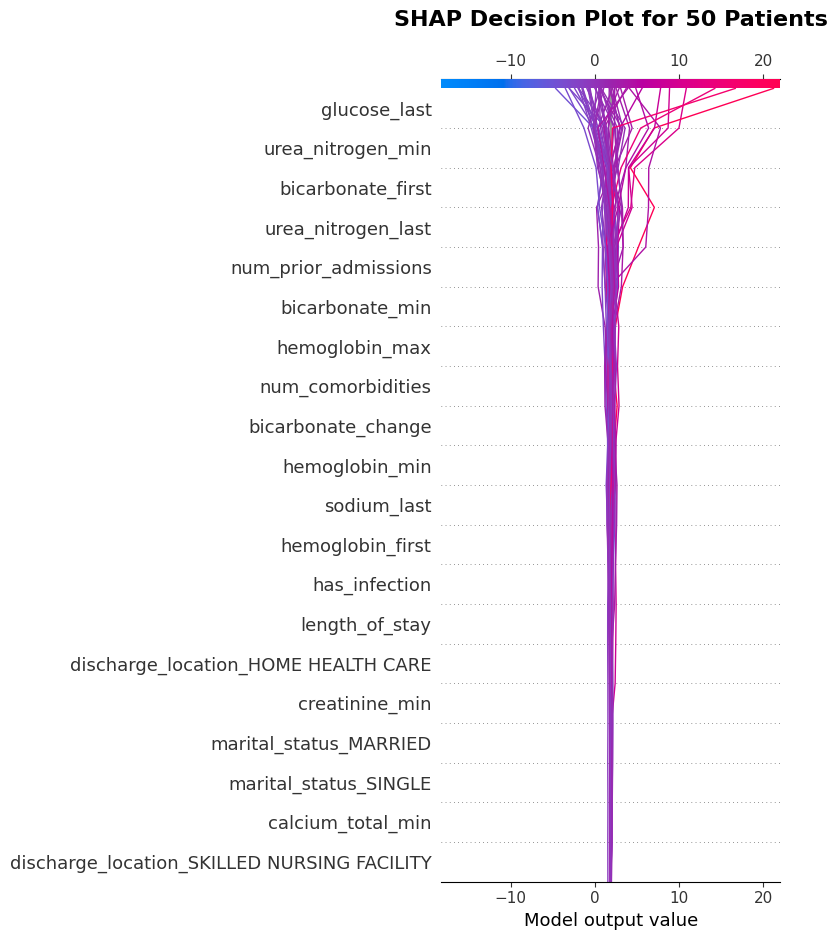

In [10]:
# 5. SHAP Decision Plot (Showing cumulative feature effects for the first 50 patients)
plt.figure(figsize=(10, 8))
# Expected value handling for newer SHAP API
expected_value = shap_values.base_values[0] if hasattr(shap_values, 'base_values') else explainer.expected_value
# Decision plots are great for showing how a model arrives at its predictions for multiple instances
shap.decision_plot(expected_value, shap_values.values[:50], features=X_test_df.iloc[:50], feature_names=feature_names, show=False)
plt.title("SHAP Decision Plot for 50 Patients", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../results/shap_decision_plot.png', dpi=300, bbox_inches='tight')
plt.show()

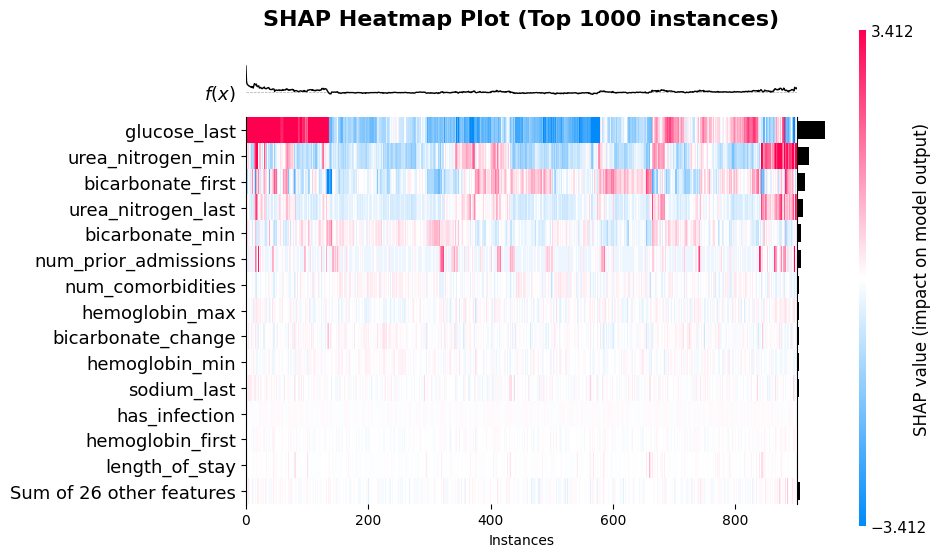

In [11]:
# 6. SHAP Heatmap Plot (Global visualization of feature impacts across patients)
plt.figure(figsize=(12, 8))
# Heatmap plot orders the samples by model output and shows the SHAP values as a heatmap
shap.plots.heatmap(shap_values[:1000], max_display=15, show=False)
plt.title("SHAP Heatmap Plot (Top 1000 instances)", fontsize=16, fontweight='bold', pad=20)
plt.savefig('../results/shap_heatmap_plot.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1200x400 with 0 Axes>

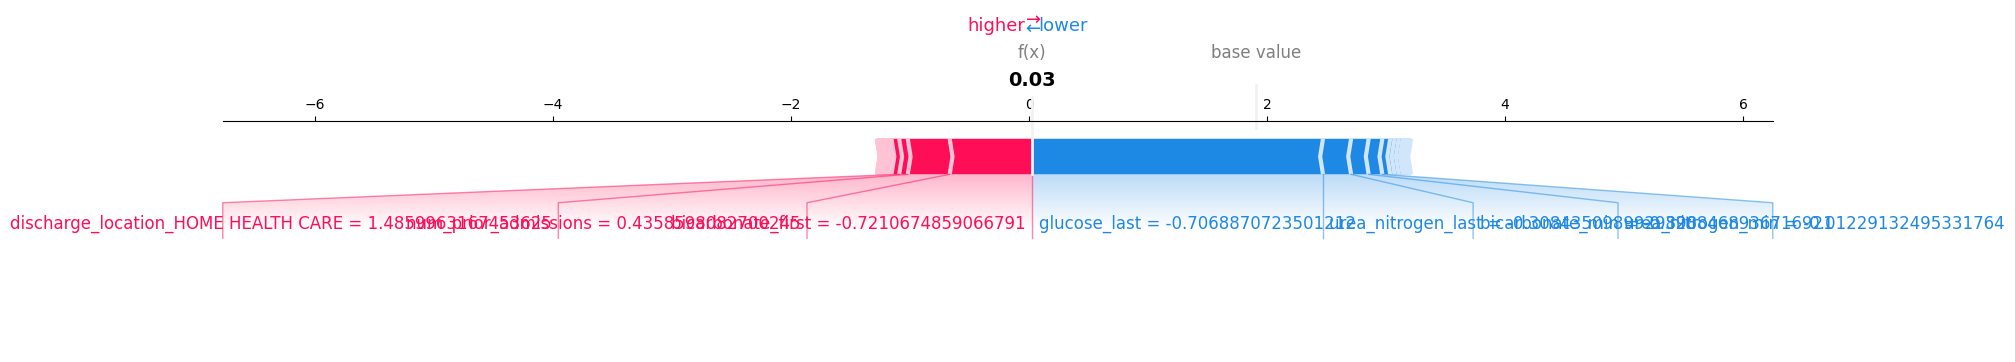

In [12]:
# 7. SHAP Force Plot for a single patient (Static Image)
plt.figure(figsize=(12, 4))
expected_value = shap_values.base_values[0] if hasattr(shap_values, 'base_values') else explainer.expected_value
# Force plots show how features push the model output from the base value
force_plot = shap.plots.force(expected_value, shap_values.values[patient_idx], features=X_test_df.iloc[patient_idx], feature_names=feature_names, matplotlib=True, show=False)
# plt.title is not well supported with matplotlib=True force plots natively, so we save directly
plt.savefig(f'../results/shap_force_patient_{patient_idx}.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
con.close()